In [1]:
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

/home/paola/anaconda3/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /home/paola/.lightkurve/cache. Please move all the files in the legacy directory /home/paola/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


In [2]:
search_result = search_lightcurve("AU Mic") 
lc2min = search_result[8].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.normalize().remove_nans()

x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)


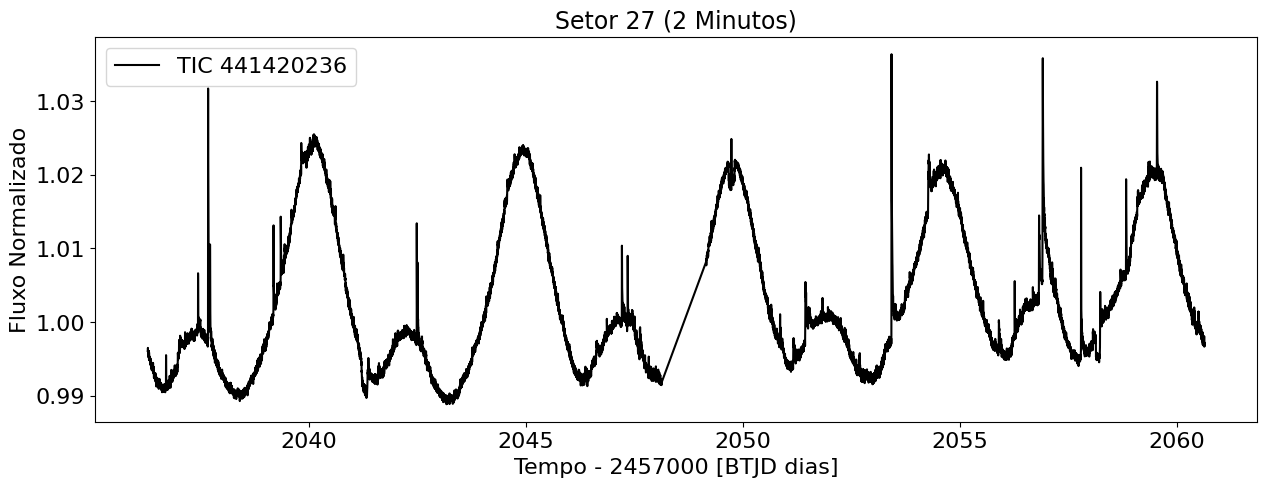

In [3]:
#%matplotlib notebook
plt.rcParams['font.size'] = '16' 
fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x2min,y2min,'k')
labels= ["TIC 441420236"]
ax.set_xlabel('Tempo - 2457000 [BTJD dias]').set_fontsize(16)
ax.set_ylabel('Fluxo Normalizado').set_fontsize(16)  
plt.title('Setor 27 (2 Minutos)').set_fontsize(17)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.legend(labels) 
plt.show()

In [4]:
vetores = [
    [2036.7054, 2036.71023],
    [2037.4429, 2037.44941],
    [2041.204,2041.404],
    [2047.4961,2047.6481],
    [2051.4334,2051.6652],
    [2053.416,2053.715],
    [2058.108,2058.276],
    [2037.663,2037.787],
    [2058.8291,2058.8768],
    [2037.6736, 2037.6953],
    [2037.71922, 2037.7435],
    [2039.18134, 2039.1888],
    [2039.82051, 2039.84413],
    [2039,1769,2039.2141],
    [2039.3400,2039.3707],
    [2039.3000,2039.3707],
    [2042.48425, 2042.49485],
    [2042.50061, 2042.51093],
    [2047.21325, 2047.2352],
    [2047.34522, 2047.35652],
    [2047.6273,2047.6467],
    [2049.6324,2049.8531],
    [2051.1540,2051.2290],
    [2051.4325,2051.5796],
    [2054.2655,2054.3711],
    [2051.438,2051.772],
    [2055.8981,2055.9470],
    [2056.8229,2056.8623],
    [2047.5068, 2047.6352],
    [2047.62795, 2047.63086],
    [2047.83154, 2047.83609],
    [2047.84043, 2047.84221],
    [2049.73685, 2049.7421],
    [2050.78104, 2050.78403],
    [2050.85602, 2050.8691],
    [2050.31549, 2050.31673],
    [2051.44131, 2051.45145],
    [2053.08171, 2053.08283],
    [2053.4107, 2053.6154],
    [2042.4797,2042.5663],
    [2058.8328,2058.8928],
    [2055.90268, 2055.90634],
    [2056.26941, 2056.27345],
    [2056.68717, 2056.70876],
    [2056.8243, 2056.83581],
    [2056.90861, 2056.92518],
    [2057.7945, 2057.9036],
    [2058.24052, 2058.24389],
    [2058.1191,2058.2976],
    [2058.8317,2058.8757],
    [2059.10883, 2059.11091],
    [2058.803,2058.912],
    [2056.9016,2057.1076],
    [2059.54703, 2059.56109]
]


vetor_true = [False]*len(x2min)


#indices = []
#indices = np.where((x2min>=vetores[0][0]) & (x2min<=vetores[0][1]))

for j in range(len(x2min)):
    for i in range(len(vetores)):
        if (x2min[j]>=vetores[i][0]) and (x2min[j]<=vetores[i][1]):
            vetor_true[j] = True

mascara = np.array(vetor_true)

#flcd = lc2_m.flatten(window_length=320, polyorder=4, return_trend=True, break_tolerance=100, niters=4, sigma=2.5, mask=mascara)
#x_detrend = np.ascontiguousarray(flcd[1].time.value, dtype=np.float64) 
#y_detrend = np.ascontiguousarray(flcd[1].flux, dtype=np.float64)
#yerr_detrend= np.ascontiguousarray(flcd[1].flux_err, dtype=np.float64)

flcd = lc2_m.flatten(window_length=320, polyorder=4, return_trend=False, break_tolerance=100, niters=4, sigma=2.5, mask=mascara)
x_detrend = np.ascontiguousarray(flcd.time.value, dtype=np.float64) 
y_detrend = np.ascontiguousarray(flcd.flux, dtype=np.float64)
#yerr_detrend= np.ascontiguousarray(flcd.flux_err, dtype=np.float64)

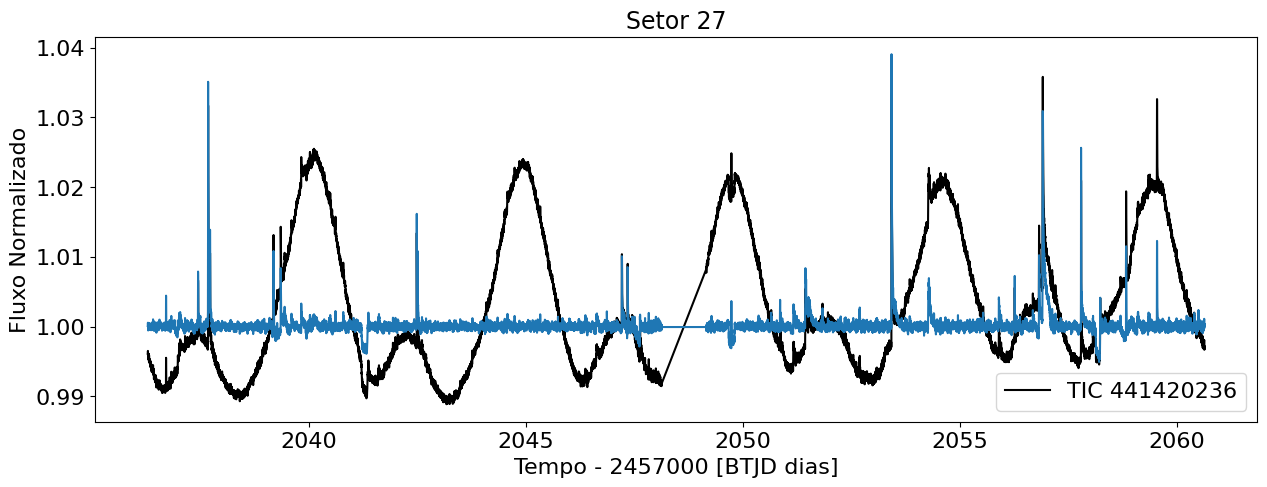

In [5]:
plt.rcParams['font.size'] = '16' 
fig,ax = plt.subplots(1,1,figsize=(15,5))
ax.plot(x2min,y2min,'k')
ax.plot(x_detrend,y_detrend, label= 'Ajuste')
labels= ["TIC 441420236"]
ax.set_xlabel('Tempo - 2457000 [BTJD dias]').set_fontsize(16)
ax.set_ylabel('Fluxo Normalizado').set_fontsize(16)  
plt.title('Setor 27').set_fontsize(17)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.legend(labels) 
plt.show()
#plt.savefig('ajuste_setor1.png', format='png')

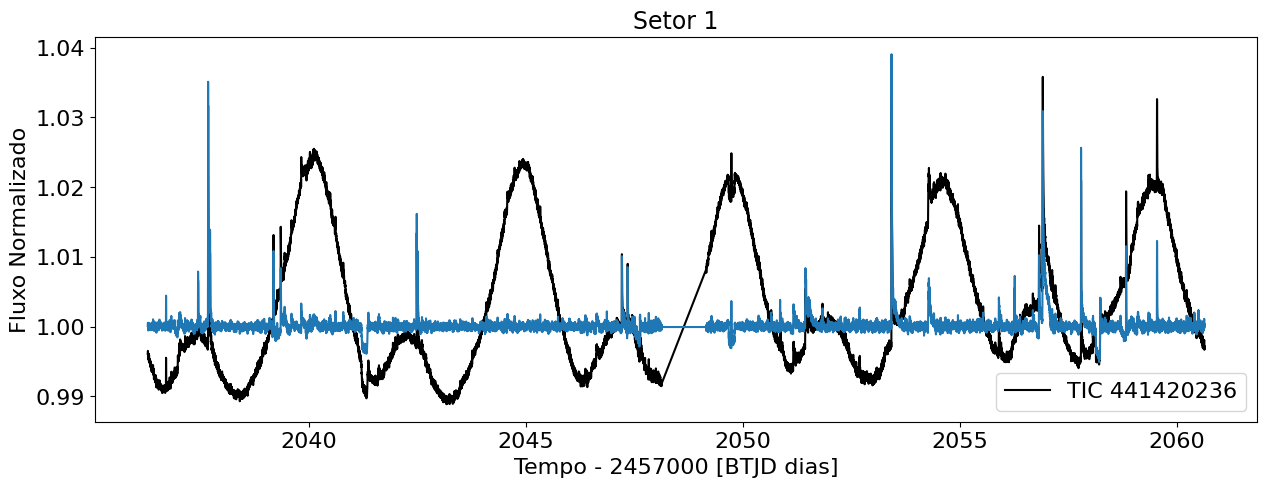

In [6]:
import matplotlib.pyplot as plt


plt.rcParams['font.size'] = 16 
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
plt.plot(x2min, y2min, 'k', label='tgfh')
plt.plot(x_detrend, y_detrend, label='Ajuste')
ax.set_xlabel('Tempo - 2457000 [BTJD dias]', fontsize=16)
ax.set_ylabel('Fluxo Normalizado', fontsize=16)  
plt.title('Setor 1', fontsize=17)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(labels, fontsize=16)  
plt.show()


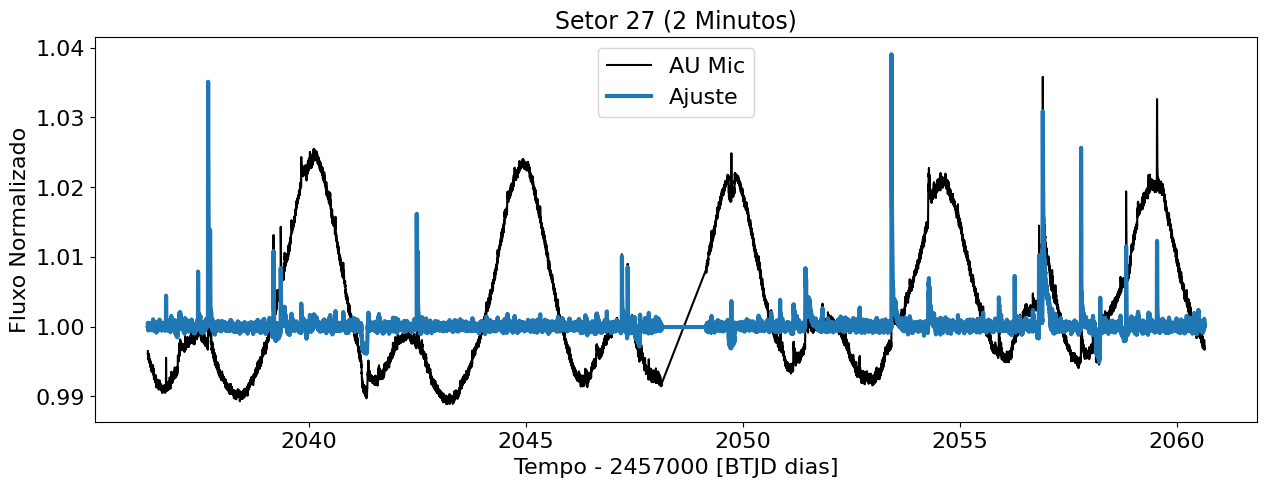

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
plt.plot(x2min, y2min, 'k', label='AU Mic')
plt.plot(x_detrend, y_detrend, linewidth=3, label="Ajuste")
plt.title('Setor 27 (2 Minutos)', fontsize=17)
plt.ylabel("Fluxo Normalizado")
plt.xlabel("Tempo - 2457000 [BTJD dias]")
plt.legend()  # Adicione esta linha para mostrar as legendas
plt.show()  # Adicione esta linha para exibir o gráfico

In [8]:
flcd.to_fits(path='lightcurve_s27_2M.fits', overwrite=True)

In [9]:
#Transformando os arquivos em fits e salvando 
from astropy.io import fits
hdu = fits.open('lightcurve_s27_2M.fits')
type(hdu)

astropy.io.fits.hdu.hdulist.HDUList

In [10]:
from astropy.table import Table
dat = Table.read('lightcurve_s27_2M.fits', format='fits')
df = dat.to_pandas()

In [11]:
print(df.isna().sum()) #Contagem de dados nans nas colunas
df = df.dropna(subset=['TIME']) 
df = df.dropna(subset=['QUALITY']) # retirar valores 
print(df.isna().sum())
df.drop(df[df.QUALITY>0].index ,inplace=True) # exclui linhas onde flag com raios cósmicos

TIME          0
FLUX          0
FLUX_ERR      0
CADENCENO     0
MOM_CENTR1    0
MOM_CENTR2    0
QUALITY       0
dtype: int64
TIME          0
FLUX          0
FLUX_ERR      0
CADENCENO     0
MOM_CENTR1    0
MOM_CENTR2    0
QUALITY       0
dtype: int64


In [12]:
%matplotlib inline
time=df["TIME"] # tempo
flux=df["FLUX"] #flux
s=df["QUALITY"] # sap_quality
sf  = df['QUALITY'] > 1 # filtra flag com valores maiores que 1 ou seja flag 128 e 8192, são raios cósmicos
#from scipy.signal import savgol_filter
rf = np.mean(flux)/np.mean(flux) #Fluxo relativo

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


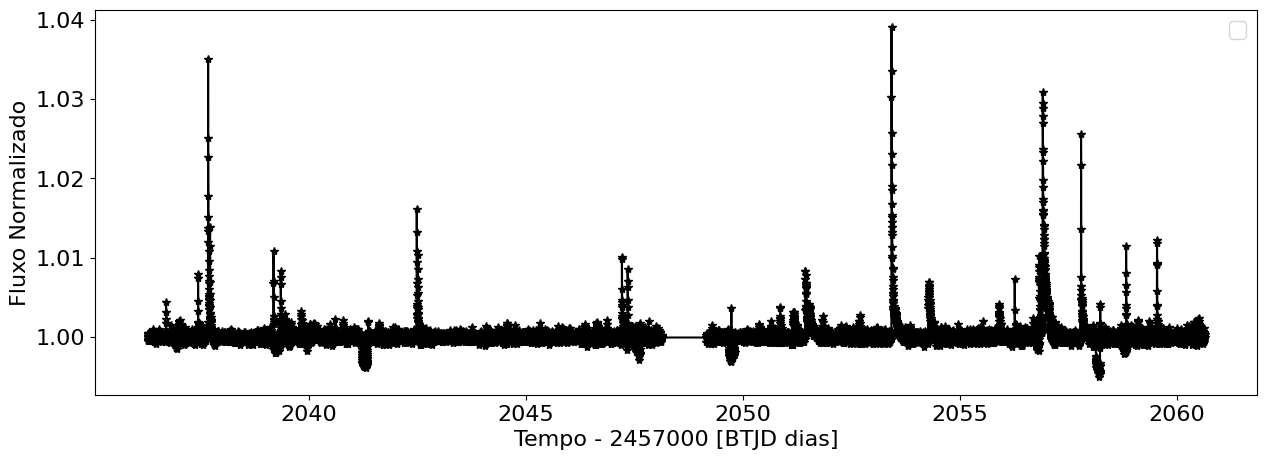

In [13]:

fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(time,flux, 'k*-')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()

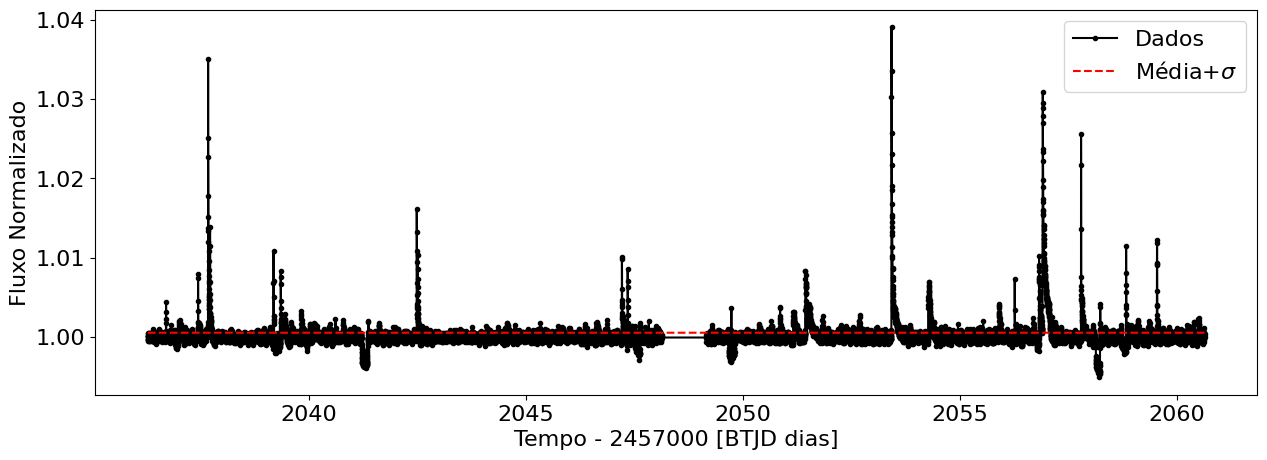

In [36]:
#%matplotlib notebook
#Calculando a média simples dos dados 
y_mean = [np.median(flux)]*len(time)

fig,ax = plt.subplots(1,1,figsize=(15,5))

data_line = ax.plot(time,flux, label='Dados', marker='.', color='black')

mean_line = ax.plot(time,y_mean+1/3*np.array(np.std(flux)), label='Média+$\sigma$', linestyle='--', color = 'red')
#mean_line = ax.plot(time,y_mean+np.std(flux), label='Mean+std', linestyle='--', color = 'red')

#Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()
plt.show()